In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import copy
from scipy.stats import wilcoxon, mannwhitneyu
import pickle as pkl
import random

import nibabel as nib

import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

from sklearn.model_selection import KFold
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import f_regression, mutual_info_regression
from sklearn.feature_selection import RFE, SequentialFeatureSelector

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, r2_score, median_absolute_error, mean_absolute_error
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from hpsklearn import HyperoptEstimator, svc

from pytorch_tabnet.tab_model import TabNetRegressor
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, anneal

import shap

import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

In [2]:
def load_unet_result(path, _print):
    unet_df = pd.read_csv(path, index_col = 'Unnamed: 0')
    index_values = []
    for _index in unet_df.index:
        index_values.append(_index.split('-seg')[0])

    unet_df.index = index_values  
    unet_df.drop(['WT jaccard', 'TC jaccard', 'ET jaccard'], axis = 1, inplace = True)
    summary_unet_df = pd.DataFrame(zip(unet_df.mean().values.tolist(), 
                                       unet_df.std().values.tolist()), 
                                   columns = ['mean', 'std'], index = unet_df.columns)
    if _print:
        print("****UNet******")
        print(summary_unet_df)
    return summary_unet_df, unet_df

def load_nnunet_result(path, _print):
    with open(path, 'r') as file:
        data = json.load(file)

    WT = []
    TC = []
    ET = []
    file_name = []
    for case in data['metric_per_case']:
        WT.append(case['metrics']['(2, 1, 3)']['Dice'])
        TC.append(case['metrics']['(2, 3)']['Dice'])
        ET.append(case['metrics']['(3,)']['Dice'])
        file_name.append(case['reference_file'].split('/')[-1].split('.')[0])

    nnunet_df = pd.DataFrame(zip(WT, TC, ET), columns = ['WT dice', 'TC dice', 'ET dice'], 
                             index = file_name)
    summary_nnunet_df = pd.DataFrame(zip(nnunet_df.mean().values.tolist(), 
                                       nnunet_df.std().values.tolist()), 
                                   columns = ['mean', 'std'], index = nnunet_df.columns)
    if _print:
        print("****nnUNet******")
        print(summary_nnunet_df)
    return summary_nnunet_df, nnunet_df

def load_TransBTS_result(path, _print):
    with open(path, 'r') as file:
        data = json.load(file)

    WT = []
    TC = []
    ET = []
    file_name = []
    for case_id in data.keys():
        case = data[case_id]
        WT.append(case['WT'][0])
        TC.append(case['TC'][0])
        ET.append(case['ET'][0])
        file_name.append(case_id)

    TransBTS_df = pd.DataFrame(zip(WT, TC, ET), columns = ['WT dice', 'TC dice', 'ET dice'], 
                             index = file_name)
    summary_TransBTS_df = pd.DataFrame(zip(TransBTS_df.mean().values.tolist(), 
                                       TransBTS_df.std().values.tolist()), 
                                   columns = ['mean', 'std'], index = TransBTS_df.columns)
    if _print:
        print("****TransBTS******")
        print(summary_TransBTS_df)
    return summary_TransBTS_df, TransBTS_df

def read_radiomics_results(analysis_type, location):
    file_name = '../Results/Analysis_Results/Radiomics/' + location + '/' + analysis_type + '.pkl'
    with open(file_name, 'rb') as f:
        results = pkl.load(f)
    return results

def read_results(_print=True):
    path = '../Results/Result/Vanilla_Unet/Unet_test_dice.csv'
    summary_unet_df, unet_df = load_unet_result(path, _print)

    path = '../Results/Result/nnUnet/nnUNetTrainer/summary.json'
    summary_da_nnunet_df, nnunet_da_df = load_nnunet_result(path, _print)

    path = '../Results/Result/nnUnet/nnUNetTrainerNoDA/summary.json'
    summary_noda_nnunet_df, nnunet_noda_df = load_nnunet_result(path, _print)

    path = '../Results/Result/TransBTS/submission/TransBTS2023-11-03/TransBTS_summary.json'
    summary_TransBTS_df, TransBTS_df = load_TransBTS_result(path, _print)
    return unet_df, nnunet_noda_df, nnunet_da_df, TransBTS_df


def get_dataset(performance_df, analysis_types, location):
    results_df = performance_df
    for analysis_type in analysis_types:
        try:
            radiomics_results_df = read_radiomics_results(analysis_type, location)
        except Exception as e:
            print(e)
            continue
        properties = {}
        property_df = pd.DataFrame()
        for i in range(len(radiomics_results_df.keys())):
            key = list(radiomics_results_df.keys())[i]
            properties[i] = key

        for i in range(len(properties)):
            selected_property = properties[i]

            property_result_df = pd.DataFrame.from_dict(radiomics_results_df[selected_property], 
                                                        orient = 'index').astype(float)
            new_col = []
            for col in property_result_df.columns:
                new_col.append(selected_property + '_' + col + '_' + analysis_type)
            property_result_df.columns = new_col
            results_df = pd.merge(property_result_df, 
                           results_df, 
                           left_index=True, 
                           right_index=True)
#             print(property_result_df.shape)

    remove_index = results_df.sort_values(['WT dice'])[0:20].index
    low_examples = results_df.loc[remove_index]
    results_df.drop(['WT dice', 'TC dice', 'ET dice'], axis=1, inplace=True)
    # results_df.drop(remove_index, axis = 0, inplace=True)
    
    return results_df, low_examples

def get_overlaps(unet_df, TransBTS_df, nnunet_noda_df, WT_dice_threshold, TC_dice_threshold, ET_dice_threshold):
    unet_df_sub = unet_df[(unet_df['WT dice'] < WT_dice_threshold) 
                          & (unet_df['TC dice'] < TC_dice_threshold) 
                          & (unet_df['ET dice'] < ET_dice_threshold)]
    
    TransBTS_df_sub = TransBTS_df[(TransBTS_df['WT dice'] < WT_dice_threshold) 
                          & (TransBTS_df['TC dice'] < TC_dice_threshold) 
                          & (TransBTS_df['ET dice'] < ET_dice_threshold)]
    
    nnunet_noda_df_sub = nnunet_noda_df[(nnunet_noda_df['WT dice'] < WT_dice_threshold) 
                          & (nnunet_noda_df['TC dice'] < TC_dice_threshold) 
                          & (nnunet_noda_df['ET dice'] < ET_dice_threshold)]

    unet_df_sub_subjects = unet_df_sub.index.values.tolist()
    TransBTS_df_sub_subjects = TransBTS_df_sub.index.values.tolist()
    nnunet_noda_df_sub_subjects = nnunet_noda_df_sub.index.values.tolist()

    all_overlaps = list(set(unet_df_sub_subjects) & set(TransBTS_df_sub_subjects) & set(nnunet_noda_df_sub_subjects))
#     print('all overlap', len(all_overlaps), unet_df_sub.shape, nnunet_noda_df_sub.shape)

    unet_nnunet_overlaps = list(set(unet_df_sub_subjects) & set(nnunet_noda_df_sub_subjects))
#     print('unet-nnunet overlap', len(unet_nnunet_overlaps))

    unet_TransBTS_overlaps = list(set(unet_df_sub_subjects) & set(TransBTS_df_sub_subjects))
#     print('unet-TransBTS overlap', len(unet_TransBTS_overlaps))

    nnunet_TransBTS_overlaps = list(set(TransBTS_df_sub_subjects) & set(nnunet_noda_df_sub_subjects))
#     print('nnunet-TransBTS overlap', len(nnunet_TransBTS_overlaps))
    
    return all_overlaps, unet_nnunet_overlaps

In [3]:
analysis_types = ['firstorder', 'shape' , 'size',
                  'glcm_1', 'glcm_5', 'glcm_10', 
                  'gldm_1', 'gldm_5', 'gldm_10', 
                  'glrlm', 'glszm', 'intensity', 
                  'ngtdm_1', 'ngtdm_5','ngtdm_10']

WT_dice_threshold= 0.91
TC_dice_threshold= 0.86
ET_dice_threshold= 0.85

unet_df, nnunet_noda_df, nnunet_da_df, TransBTS_df = read_results(False)
performance_df = unet_df

all_overlaps, unet_nnunet_overlaps = get_overlaps(unet_df, 
                                                TransBTS_df, 
                                                nnunet_noda_df, 
                                                WT_dice_threshold, 
                                                TC_dice_threshold, 
                                                ET_dice_threshold)

In [4]:
location = 'Tumor_WT'

# Shape

In [5]:
shape_features = ["original_shape_Elongation_flair_shape",
            "original_shape_Flatness_flair_shape",
            "original_shape_LeastAxisLength_flair_shape",
            "original_shape_MajorAxisLength_flair_shape",
            "original_shape_MinorAxisLength_flair_shape",
            "original_shape_Sphericity_flair_shape"]

analysis_types = ['shape']


shape_df, _ = get_dataset(performance_df, analysis_types, location)
shape_df = shape_df[shape_features]
shape_df.shape

(938, 6)

# Size

In [6]:
size_features = ["diagnostics_Mask-original_VolumeNum_flair_size",
            "original_shape_MeshVolume_flair_size",
            "original_shape_SurfaceArea_flair_size",
            "original_shape_SurfaceVolumeRatio_flair_size"]

analysis_types = ['size']

size_df, _ = get_dataset(performance_df, analysis_types, location)
size_df = size_df[size_features]
size_df.shape

(938, 4)

# Intensity

In [7]:
intensity_features = ["diagnostics_Image-original_Mean_flair_intensity",
            "diagnostics_Image-original_Mean_t2_intensity",
            "diagnostics_Image-original_Mean_t1_intensity",
            "diagnostics_Image-original_Mean_t1ce_intensity",
            "diagnostics_Image-original_Maximum_flair_intensity",
            "diagnostics_Image-original_Maximum_t2_intensity",
            "diagnostics_Image-original_Maximum_t1_intensity",
            "diagnostics_Image-original_Maximum_t1ce_intensity"]

analysis_types = ['intensity']

intensity_df, _ = get_dataset(performance_df, analysis_types, location)
intensity_df = intensity_df[intensity_features]
intensity_df.shape

(938, 8)

# First Order Statistics

In [8]:
firstorder_features = ["original_firstorder_Energy_flair_firstorder",
            "original_firstorder_Energy_t2_firstorder",
            "original_firstorder_Energy_t1_firstorder",
            "original_firstorder_Energy_t1ce_firstorder",
            "original_firstorder_Entropy_flair_firstorder",
            "original_firstorder_Entropy_t2_firstorder",
            "original_firstorder_Entropy_t1_firstorder",
            "original_firstorder_Entropy_t1ce_firstorder",
            "original_firstorder_Kurtosis_flair_firstorder",
            "original_firstorder_Kurtosis_t2_firstorder",
            "original_firstorder_Kurtosis_t1_firstorder",
            "original_firstorder_Kurtosis_t1ce_firstorder",
            "original_firstorder_Skewness_flair_firstorder",
            "original_firstorder_Skewness_t2_firstorder",
            "original_firstorder_Skewness_t1_firstorder",
            "original_firstorder_Skewness_t1ce_firstorder",
            "original_firstorder_Uniformity_flair_firstorder",
            "original_firstorder_Uniformity_t2_firstorder",
            "original_firstorder_Uniformity_t1_firstorder",
            "original_firstorder_Uniformity_t1ce_firstorder"]

analysis_types = ['firstorder']

firstorder_df, _ = get_dataset(performance_df, analysis_types, location)
firstorder_df = firstorder_df[firstorder_features]
firstorder_df.shape

(938, 20)

# Neighbouring Gray Tone Difference Matrix (NGTDM) features

In [9]:
ngtdm_features = ["original_ngtdm_Busyness_flair_ngtdm_10",
        "original_ngtdm_Busyness_t2_ngtdm_10",
        "original_ngtdm_Busyness_t1_ngtdm_10",
        "original_ngtdm_Busyness_t1ce_ngtdm_10",
        "original_ngtdm_Coarseness_flair_ngtdm_10",
        "original_ngtdm_Coarseness_t2_ngtdm_10",
        "original_ngtdm_Coarseness_t1_ngtdm_10",
        "original_ngtdm_Coarseness_t1ce_ngtdm_10",
        "original_ngtdm_Complexity_flair_ngtdm_10",
        "original_ngtdm_Complexity_t2_ngtdm_10",
        "original_ngtdm_Complexity_t1_ngtdm_10",
        "original_ngtdm_Complexity_t1ce_ngtdm_10",
        "original_ngtdm_Contrast_flair_ngtdm_10",
        "original_ngtdm_Contrast_t2_ngtdm_10",
        "original_ngtdm_Contrast_t1_ngtdm_10",
        "original_ngtdm_Contrast_t1ce_ngtdm_10",
        "original_ngtdm_Strength_flair_ngtdm_10",
        "original_ngtdm_Strength_t2_ngtdm_10",
        "original_ngtdm_Strength_t1_ngtdm_10",
        "original_ngtdm_Strength_t1ce_ngtdm_10", ]


analysis_types = ['ngtdm_10']

ngtdm_df, _ = get_dataset(performance_df, analysis_types, location)
# ngtdm_df = ngtdm_df[ngtdm_features]
ngtdm_df.shape

(938, 20)

# Gray Level Co-occurrence Matrix (GLCM) Features

In [10]:
glcm_features = ["original_glcm_Autocorrelation_flair_glcm_10",
        "original_glcm_Autocorrelation_t2_glcm_10",
        "original_glcm_Autocorrelation_t1_glcm_10",
        "original_glcm_Autocorrelation_t1ce_glcm_10",
        "original_glcm_ClusterProminence_flair_glcm_10",
        "original_glcm_ClusterProminence_t2_glcm_10",
        "original_glcm_ClusterProminence_t1_glcm_10",
        "original_glcm_ClusterProminence_t1ce_glcm_10",
        "original_glcm_ClusterShade_flair_glcm_10",
        "original_glcm_ClusterShade_t2_glcm_10",
        "original_glcm_ClusterShade_t1_glcm_10",
        "original_glcm_ClusterShade_t1ce_glcm_10",
        "original_glcm_ClusterTendency_flair_glcm_10",
        "original_glcm_ClusterTendency_t2_glcm_10",
        "original_glcm_ClusterTendency_t1_glcm_10",
        "original_glcm_ClusterTendency_t1ce_glcm_10",
        "original_glcm_Contrast_flair_glcm_10",
        "original_glcm_Contrast_t2_glcm_10",
        "original_glcm_Contrast_t1_glcm_10",
        "original_glcm_Contrast_t1ce_glcm_10",
        "original_glcm_Correlation_flair_glcm_10",
        "original_glcm_Correlation_t2_glcm_10",
        "original_glcm_Correlation_t1_glcm_10",
        "original_glcm_Correlation_t1ce_glcm_10",
        "original_glcm_JointAverage_flair_glcm_10",
        "original_glcm_JointAverage_t2_glcm_10",
        "original_glcm_JointAverage_t1_glcm_10",
        "original_glcm_JointAverage_t1ce_glcm_10",
        "original_glcm_JointEnergy_flair_glcm_10",
        "original_glcm_JointEnergy_t2_glcm_10",
        "original_glcm_JointEnergy_t1_glcm_10",
        "original_glcm_JointEnergy_t1ce_glcm_10",
        "original_glcm_JointEntropy_flair_glcm_10",
        "original_glcm_JointEntropy_t2_glcm_10",
        "original_glcm_JointEntropy_t1_glcm_10",
        "original_glcm_JointEntropy_t1ce_glcm_10",
        "original_glcm_MCC_flair_glcm_10",
        "original_glcm_MCC_t2_glcm_10",
        "original_glcm_MCC_t1_glcm_10",
        "original_glcm_MCC_t1ce_glcm_10"]


analysis_types = ['glcm_10']

glcm_df, _ = get_dataset(performance_df, analysis_types, location)
# glcm_df = glcm_df[glcm_features]
glcm_df.shape

(938, 96)

# Gray Level Dependence Matrix (GLDM) Features

In [11]:
gldm_features = ["original_gldm_DependenceNonUniformity_flair_gldm_10",
        "original_gldm_DependenceNonUniformity_t2_gldm_10",
        "original_gldm_DependenceNonUniformity_t1_gldm_10",
        "original_gldm_DependenceNonUniformity_t1ce_gldm_10",
        "original_gldm_GrayLevelNonUniformity_flair_gldm_10",
        "original_gldm_GrayLevelNonUniformity_t2_gldm_10",
        "original_gldm_GrayLevelNonUniformity_t1_gldm_10",
        "original_gldm_GrayLevelNonUniformity_t1ce_gldm_10",
        "original_gldm_GrayLevelVariance_flair_gldm_10",
        "original_gldm_GrayLevelVariance_t2_gldm_10",
        "original_gldm_GrayLevelVariance_t1_gldm_10",
        "original_gldm_GrayLevelVariance_t1ce_gldm_10",
        "original_gldm_HighGrayLevelEmphasis_flair_gldm_10",
        "original_gldm_HighGrayLevelEmphasis_t2_gldm_10",
        "original_gldm_HighGrayLevelEmphasis_t1_gldm_10",
        "original_gldm_HighGrayLevelEmphasis_t1ce_gldm_10",
        "original_gldm_LargeDependenceEmphasis_flair_gldm_10",
        "original_gldm_LargeDependenceEmphasis_t2_gldm_10",
        "original_gldm_LargeDependenceEmphasis_t1_gldm_10",
        "original_gldm_LargeDependenceEmphasis_t1ce_gldm_10",
        "original_gldm_LowGrayLevelEmphasis_flair_gldm_10",
        "original_gldm_LowGrayLevelEmphasis_t2_gldm_10",
        "original_gldm_LowGrayLevelEmphasis_t1_gldm_10",
        "original_gldm_LowGrayLevelEmphasis_t1ce_gldm_10",
        "original_gldm_SmallDependenceEmphasis_flair_gldm_10",
        "original_gldm_SmallDependenceEmphasis_t2_gldm_10",
        "original_gldm_SmallDependenceEmphasis_t1_gldm_10",
        "original_gldm_SmallDependenceEmphasis_t1ce_gldm_10"]


analysis_types = ['gldm_10']

gldm_df, _ = get_dataset(performance_df, analysis_types, location)
# gldm_df = gldm_df[gldm_features]
gldm_df.shape

(938, 56)

# Gray Level Run Length Matrix (GLRLM) Features

In [12]:
glrlm_features = ["original_glrlm_GrayLevelNonUniformity_flair_glrlm",
        "original_glrlm_GrayLevelNonUniformity_t2_glrlm",
        "original_glrlm_GrayLevelNonUniformity_t1_glrlm",
        "original_glrlm_GrayLevelNonUniformity_t1ce_glrlm",
        "original_glrlm_LongRunEmphasis_flair_glrlm",
        "original_glrlm_LongRunEmphasis_t2_glrlm",
        "original_glrlm_LongRunEmphasis_t1_glrlm",
        "original_glrlm_LongRunEmphasis_t1ce_glrlm",
        "original_glrlm_LongRunHighGrayLevelEmphasis_flair_glrlm",
        "original_glrlm_LongRunHighGrayLevelEmphasis_t2_glrlm",
        "original_glrlm_LongRunHighGrayLevelEmphasis_t1_glrlm",
        "original_glrlm_LongRunHighGrayLevelEmphasis_t1ce_glrlm",
        "original_glrlm_LongRunLowGrayLevelEmphasis_flair_glrlm",
        "original_glrlm_LongRunLowGrayLevelEmphasis_t2_glrlm",
        "original_glrlm_LongRunLowGrayLevelEmphasis_t1_glrlm",
        "original_glrlm_LongRunLowGrayLevelEmphasis_t1ce_glrlm",
        "original_glrlm_LowGrayLevelRunEmphasis_flair_glrlm",
        "original_glrlm_LowGrayLevelRunEmphasis_t2_glrlm",
        "original_glrlm_LowGrayLevelRunEmphasis_t1_glrlm",
        "original_glrlm_LowGrayLevelRunEmphasis_t1ce_glrlm",
        "original_glrlm_RunLengthNonUniformity_flair_glrlm",
        "original_glrlm_RunLengthNonUniformity_t2_glrlm",
        "original_glrlm_RunLengthNonUniformity_t1_glrlm",
        "original_glrlm_RunLengthNonUniformity_t1ce_glrlm",
        "original_glrlm_RunPercentage_flair_glrlm",
        "original_glrlm_RunPercentage_t2_glrlm",
        "original_glrlm_RunPercentage_t1_glrlm",
        "original_glrlm_RunPercentage_t1ce_glrlm",
        "original_glrlm_ShortRunEmphasis_flair_glrlm",
        "original_glrlm_ShortRunEmphasis_t2_glrlm",
        "original_glrlm_ShortRunEmphasis_t1_glrlm",
        "original_glrlm_ShortRunEmphasis_t1ce_glrlm",
        "original_glrlm_ShortRunHighGrayLevelEmphasis_flair_glrlm",
        "original_glrlm_ShortRunHighGrayLevelEmphasis_t2_glrlm",
        "original_glrlm_ShortRunHighGrayLevelEmphasis_t1_glrlm",
        "original_glrlm_ShortRunHighGrayLevelEmphasis_t1ce_glrlm",
        "original_glrlm_ShortRunLowGrayLevelEmphasis_flair_glrlm",
        "original_glrlm_ShortRunLowGrayLevelEmphasis_t2_glrlm",
        "original_glrlm_ShortRunLowGrayLevelEmphasis_t1_glrlm",
        "original_glrlm_ShortRunLowGrayLevelEmphasis_t1ce_glrlm"]


analysis_types = ['glrlm']

glrlm_df, _ = get_dataset(performance_df, analysis_types, location)
# glrlm_df = glrlm_df[glrlm_features]
glrlm_df.shape

(938, 64)

# Gray Level Size Zone Matrix (GLSZM) Features

In [13]:
glszm_features = ["original_glszm_LargeAreaEmphasis_flair_glszm",
        "original_glszm_LargeAreaEmphasis_t2_glszm",
        "original_glszm_LargeAreaEmphasis_t1_glszm",
        "original_glszm_LargeAreaEmphasis_t1ce_glszm",
        "original_glszm_SizeZoneNonUniformity_flair_glszm",
        "original_glszm_SizeZoneNonUniformity_t2_glszm",
        "original_glszm_SizeZoneNonUniformity_t1_glszm",
        "original_glszm_SizeZoneNonUniformity_t1ce_glszm",
        "original_glszm_SmallAreaEmphasis_flair_glszm",
        "original_glszm_SmallAreaEmphasis_t2_glszm",
        "original_glszm_SmallAreaEmphasis_t1_glszm",
        "original_glszm_SmallAreaEmphasis_t1ce_glszm",
        "original_glszm_ZoneEntropy_flair_glszm",
        "original_glszm_ZoneEntropy_t2_glszm",
        "original_glszm_ZoneEntropy_t1_glszm",
        "original_glszm_ZoneEntropy_t1ce_glszm"]


analysis_types = ['glszm']

glszm_df, _ = get_dataset(performance_df, analysis_types, location)
# glszm_df = glszm_df[glszm_features]
glszm_df.shape

(938, 64)

# Volume

In [14]:
volume_df = pd.read_csv('../Results/Analysis_Results/volume/GLI-Tumor_volumns.csv', 
                         index_col='Unnamed: 0')



volume_df = volume_df[['ED', 'ET', 'NCR', 'WT_volume', 'TC_volume', 'ET_volume', 'TC_WT_ratio',
       'ET_WT_ratio', 'ET_TC_ratio']]

volume_df.shape

(939, 9)

# Probability

In [15]:
Probability_df = pd.read_csv('../Results/Analysis_Results/probability/Probability_Tumor_boundary.csv', 
                             index_col='Unnamed: 0')

Probability_df.shape

(939, 9)

# Curverature

In [16]:
Curverature_df = pd.read_csv('../Results/Analysis_Results/curverature/curverature.csv', 
                             index_col='Unnamed: 0')

Curverature_df = Curverature_df[['mean_gaussian_curvature', 'std_gaussian_curvature', 
                                'pos', 'neg',
                                'pos_count', 'neg_count']]

Curverature_df.shape

(939, 6)

# Saliency

In [17]:
Saliency_df = pd.read_csv('../Results/Analysis_Results/Saliency/Saliency.csv', 
                             index_col='Unnamed: 0')

Saliency_df.shape

(939, 12)

# Combine Features

In [18]:
results_df = pd.merge(shape_df, 
                       size_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       intensity_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       volume_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       Curverature_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       Saliency_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       Probability_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       firstorder_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       ngtdm_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       glcm_df, 
                       left_index=True, 
                       right_index=True)

# # results_df = pd.merge(ngtdm_df, 
# #                        glcm_df, 
# #                        left_index=True, 
# #                        right_index=True)



results_df = pd.merge(results_df, 
                       gldm_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       glrlm_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       glszm_df, 
                       left_index=True, 
                       right_index=True)


results_df = pd.merge(results_df, 
                       performance_df, 
                       left_index=True, 
                       right_index=True)

In [19]:
results_df = results_df.T.drop_duplicates()
results_df = results_df.T

In [20]:
results_df = results_df.dropna()
results_df.shape

(932, 376)

In [21]:
# sub_df = results_df#[selected_metrics]
# sub_df.drop(['WT dice', 'TC dice', 'ET dice'], axis=1, inplace=True)  # Features
# corr = sub_df.corr('spearman')
# corr = corr.abs()

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# from scipy.cluster import hierarchy

# # Assuming `df` is your DataFrame
# # Calculate the correlation matrix


# # Perform hierarchical clustering
# corr_linkage = hierarchy.ward(corr)

# # Create a dendrogram to get the order of leaves
# dendro = hierarchy.dendrogram(corr_linkage, no_plot=True)
# order = dendro['leaves']

# # Reorder the correlation matrix according to the clustering
# corr_ordered = corr.iloc[order, order]

# # Set up the matplotlib figure
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# # Plot the dendrogram
# hierarchy.dendrogram(corr_linkage, ax=ax1, orientation='left', labels=corr.index[order])
# ax1.set_title('Hierarchical Clustering Dendrogram')

# # Plot the clustered correlation matrix
# sns.heatmap(corr_ordered, ax=ax2, annot=False, cmap='coolwarm', center=0)
# ax2.set_title("Clustered Correlation Matrix")

# plt.tight_layout()

In [ ]:
# # Determine the clusters, here using a threshold to cut the dendrogram
# threshold = 8  # Adjust this value as needed
# clusters = hierarchy.fcluster(corr_linkage, threshold, criterion='distance')

# # Create a dictionary to hold the clusters
# cluster_dict = {}
# for i, cluster_id in enumerate(clusters):
#     if cluster_id not in cluster_dict:
#         cluster_dict[cluster_id] = []
#     cluster_dict[cluster_id].append(corr.columns[i])

In [ ]:
# cluster_dict.keys()

# Build Model

In [ ]:
# def train_model(X_train, y_train):
#     # Initialize the Gradient Boosting Regressor
#     model = GradientBoostingRegressor(n_estimators=100, 
#                                       learning_rate=0.1, 
#                                       max_depth=2, 
#                                       random_state=42)
    
#     # Train the model
#     model.fit(X_train, y_train)
#     return model

# def test_model(model, X_test):
#     # Predict on the testing set
#     y_pred = model.predict(X_test)
#     return y_pred

# def normalize_data(X):
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)
#     return scaler, X_scaled

# # def select_features(X_train, y_train):
# #     # rfe = RFE(estimator=model, n_features_to_select=20)
# #     sfs = SequentialFeatureSelector(estimator = model, 
# #                                     n_features_to_select = 15, 
# #                                     scoring = 'neg_mean_absolute_error', 
# #                                     n_jobs=4)
# #     sfs.fit(X_train_scaled, y_train)

# #     selected_features = sfs.get_feature_names_out()

# #     # Print the selected features
# #     print("Selected features:", selected_features)
    
# #     return selected_features

# def select_features(X_train, y_train):
#     # rfe = RFE(estimator=model, n_features_to_select=20)
#     mir = mutual_info_regression(X_train_scaled, y_train)
    
#     select_df = pd.DataFrame(zip(X_train_scaled.columns, mir), columns = ['features', 'score'])

#     selected_features = select_df.sort_values(['score'], ascending=False)[0:50].features.values.tolist()

#     # Print the selected features
# #     print("Selected features:", selected_features)
    
#     return selected_features

##  Train Baseline Model

In [46]:
# Separate features and target variable
results_df.reset_index(drop=True, inplace=True)
X = results_df.drop(['WT dice', 'TC dice', 'ET dice'], axis=1)  # Features
y = results_df['WT dice']  # Target variable (Dice score)

In [23]:
# Normalize features
scaler = StandardScaler()
_X = scaler.fit_transform(X)
X = pd.DataFrame(_X, columns=X.columns)


# Split data into training and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
import pyswarms as ps
# Define binary PSO
# Define binary PSO
def f_per_particle(m, alpha):
    """ Computes the objective function per particle

    Inputs
    ------
    m : numpy.ndarray
        Binary mask that can be used to select features
    alpha : float
        Penalty factor to control the number of selected features
    
    Returns
    -------
    float
        Computed objective function
    """
    if np.count_nonzero(m) == 0:
        return float('inf') # Penalize empty feature sets

    # Apply mask to features
    X_subset = X_train[:,m==1]

    # Train a regression model
    regressor = GradientBoostingRegressor(random_state=42)
    regressor.fit(X_subset, y_train)
    
    # Make predictions and calculate MSE
    X_test_subset = X_test[:,m==1]
    predictions = regressor.predict(X_test_subset)
    mse = mean_absolute_error(y_test, predictions)
    
    # Objective function
    j = alpha * mse + (1 - alpha) * (np.sum(m) / X.shape[1])
    return j

def f(x, alpha=0.88):  # Adjust alpha to balance between MSE and feature count
    """ Higher-level method to do regression in the whole swarm.
    
    Inputs
    ------
    x : numpy.ndarray of shape (n_particles, dimensions)
        The swarm that will perform the search
    
    Returns
    -------
    numpy.ndarray of shape (n_particles, )
        The computed loss for each particle
    """
    n_particles = x.shape[0]
    j = [f_per_particle(x[i], alpha) for i in range(n_particles)]
    return np.array(j)

In [ ]:
# # Initialize swarm, arbitrary binary matrix (positions)
# options = {'c1': 0.5, 'c2': 0.3, 'w':0.9, 'k': 30, 'p':2}
# dimensions = X.shape[1]  # number of features
# optimizer = ps.discrete.BinaryPSO(n_particles=30, dimensions=dimensions, options=options)

# # Perform optimization
# cost, pos = optimizer.optimize(f, iters=100)

In [ ]:
# # Get the selected features from the final position
# X = results_df.drop(['WT dice', 'TC dice', 'ET dice'], axis=1)

# selected_features = X.columns[pos > 0]
# print("Selected features:", selected_features)


In [ ]:
# from sklearn.feature_selection import mutual_info_regression
# info = mutual_info_regression(X, y)
# print(X.shape, len(info))
# columns_df = pd.DataFrame(zip(X.columns,info), columns = ['Name', 'info'])
# columns_df = columns_df.sort_values(['info'], ascending=False)
# X = X[columns_df.Name[0:10]]

In [ ]:
# from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
# from sklearn.linear_model import LinearRegression

# warnings.filterwarnings("ignore", category=FutureWarning)
# lr = GradientBoostingRegressor()

# efs = EFS(lr, 
#           min_features=5,
#           max_features=X.shape[1]-1,
#           scoring='neg_mean_absolute_error',
#           cv=5, 
#           n_jobs=4, 
#           print_progress=True)
# efs.fit(X, y)

# print('Best MSE score: %.2f' % efs.best_score_ * (-1))
# print('Best subset:', efs.best_idx_)

In [ ]:
# from sklearn.feature_selection import SequentialFeatureSelector
# lr = GradientBoostingRegressor()
# sfs = SequentialFeatureSelector(lr, tol=0.001, scoring = 'neg_mean_absolute_error')
# sfs.fit(X, y)
# f = sfs.get_support()
# selected_features_df = pd.DataFrame(zip(X.columns, f), columns = ['name','selected'])
# subset_selected = selected_features_df[selected_features_df['selected'] == True].name.values.tolist()
# X = X[subset_selected]

In [ ]:
# mses = []
# maes = []
# r2s = []

# for numb in [42,67,87,12,94]:
#     kf = KFold(n_splits=5, shuffle = True, random_state=numb)
#     for i, (train_index, test_index) in enumerate(kf.split(X)):
#         X_train, y_train = X.loc[train_index], y.loc[train_index]
#         X_test, y_test = X.loc[test_index], y.loc[test_index]

#         # Standardize the features
#         scaler = StandardScaler()
#         X_train_scaled = scaler.fit_transform(X_train)
#         X_test_scaled = scaler.transform(X_test)

#         X_train_scaled = pd.DataFrame(X_train_scaled, columns = X.columns)
#         X_test_scaled = pd.DataFrame(X_test_scaled, columns = X.columns)

#         model = GradientBoostingRegressor(n_estimators=100, 
#                                       learning_rate=0.1, 
#                                       max_depth=2, 
#                                       random_state=42)

#         model.fit(X_train_scaled, y_train)
#         y_pred = model.predict(X_test_scaled)

#         # Evaluate the model
#         mse = round(mean_squared_error(y_test, y_pred),3)
#         mae = round(mean_absolute_error(y_test, y_pred),3)
#         r2 = round(r2_score(y_test, y_pred),3)

#         mses.append(mse)
#         maes.append(mae)
#         r2s.append(r2)

In [50]:
from sklearn.decomposition import PCA
pca = PCA(n_components=80)
X_New = pca.fit_transform(X)

In [51]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from hyperopt import hp, fmin, tpe, Trials, anneal
import pandas as pd
import numpy as np

# Assuming results_df is your DataFrame with the data
# X = results_df.drop(['WT dice', 'TC dice', 'ET dice'], axis=1)  # Features
# y = results_df['WT dice']  # Target variable (Dice score)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_New, y, test_size=0.2, random_state=42)

# lr = GradientBoostingRegressor()
# sfs = SequentialFeatureSelector(lr, tol=0.0001, scoring = 'neg_mean_absolute_error')
# sfs.fit(X_train, y_train)

# selected_features = sfs.get_support()
# selected_features_df = pd.DataFrame(zip(X.columns, selected_features), columns = ['name','selected'])

# subset_selected = selected_features_df[selected_features_df['selected'] == True].name.values.tolist()
# X_train = X_train[subset_selected]
# X_test = X_test[subset_selected] 

# Define the hyperparameter space
space = {
    'loss': hp.choice('loss', ['squared_error', 'absolute_error', 'huber', 'quantile']),
    'learning_rate': hp.uniform('learning_rate', 0.01, 1),
    'n_estimators': hp.quniform('n_estimators', 10, 300, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'criterion': hp.choice('criterion', ['friedman_mse', 'squared_error']),
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 5, 1),
    'min_weight_fraction_leaf': hp.uniform('min_weight_fraction_leaf', 0.0, 0.5),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),  # now using quniform
    'min_impurity_decrease': hp.uniform('min_impurity_decrease', 0.0, 0.1),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2']),
    'alpha': hp.uniform('alpha', 0.01, 0.99),
    'max_leaf_nodes': hp.quniform('max_leaf_nodes', 10, 50, 1),  # now using quniform
    'validation_fraction': hp.uniform('validation_fraction', 0.1, 0.3),
#     'n_iter_no_change': hp.choice('n_iter_no_change', [None, 5, 10, 15]),
    'tol': hp.uniform('tol', 1e-5, 1e-3),
    'ccp_alpha': hp.uniform('ccp_alpha', 0.0, 0.1)
}

def objective(params):
    # Ensure integer parameters are properly cast
    params['n_estimators'] = int(params['n_estimators'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['max_depth'] = int(params['max_depth']) if params['max_depth'] is not None else None
    params['max_leaf_nodes'] = int(params['max_leaf_nodes']) if params['max_leaf_nodes'] is not None else None

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    model = GradientBoostingRegressor(random_state=42, **params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae = -np.mean(cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error'))
    return {'loss': mae, 'status': STATUS_OK}

# Run the hyperparameter optimization
trials = Trials()
best = fmin(fn=objective, space=space, algo=anneal.suggest, max_evals=100, trials=trials)

best_params = {
        'loss': ['squared_error', 'absolute_error', 'huber', 'quantile'][best['loss']],
        'learning_rate': best['learning_rate'],
        'n_estimators': int(best['n_estimators']),
        'subsample': best['subsample'],
        'criterion': ['friedman_mse', 'squared_error'][best['criterion']],
        'min_samples_split': int(best['min_samples_split']),
        'min_samples_leaf': int(best['min_samples_leaf']),
        'min_weight_fraction_leaf': best['min_weight_fraction_leaf'],
        'max_depth': int(best['max_depth']),
        'min_impurity_decrease': best['min_impurity_decrease'],
        'max_features': [None, 'sqrt', 'log2'][best['max_features']],
        'ccp_alpha': best['ccp_alpha']
    }

print(best_params)

# Train the final model on the entire training set with the best hyperparameters
best_model = GradientBoostingRegressor(random_state=42, **best_params)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_model.fit(X_train_scaled, y_train)

# Evaluate the final model on the test set
y_pred = best_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
medae = round(median_absolute_error(y_test, y_pred),3)
r2 = r2_score(y_test, y_pred)

print(f"Final Model Evaluation on Test Set:\nMSE: {mse:.3f}\nMAE: {mae:.3f}\nR2: {r2:.3f} \nMEDAE : {medae:.3f}")


 60%|███████████████████████████████████████████████████▌                                  | 60/100 [07:51<05:14,  7.86s/trial, best loss: 0.05338969830055584]


KeyboardInterrupt: 

In [73]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, anneal

# Assuming results_df is your DataFrame with the data
# X = results_df.drop(['WT dice', 'TC dice', 'ET dice'], axis=1)  # Features
# y = results_df['WT dice']  # Target variable (Dice score)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the hyperparameter space
space = {
    'max_depth': hp.choice('max_depth', [3, 4, 5, 6, 7, 8, 9, 10]),
    'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'n_estimators': hp.quniform('n_estimators', 100, 1000, 50),
    'reg_alpha': hp.uniform('reg_alpha', 0.0, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 1, 4)
}

def objective(params):
    params['n_estimators'] = int(params['n_estimators'])
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    model = XGBRegressor(random_state=42, **params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae = -np.mean(cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_absolute_error'))
    return {'loss': mae, 'status': STATUS_OK}

# Run the hyperparameter optimization
trials = Trials()
best = fmin(fn=objective, space=space, algo=anneal.suggest, max_evals=100, trials=trials)

best_params = {
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10][best['max_depth']],
    'min_child_weight': int(best['min_child_weight']),
    'gamma': best['gamma'],
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'learning_rate': best['learning_rate'],
    'n_estimators': int(best['n_estimators']),
    'reg_alpha': best['reg_alpha'],
    'reg_lambda': best['reg_lambda']
}

print("Best hyperparameters:", best_params)

# Train the final model on the entire training set with the best hyperparameters
best_model = XGBRegressor(random_state=42, **best_params)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_model.fit(X_train_scaled, y_train)

# Evaluate the final model on the test set
y_pred = best_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
medae = round(median_absolute_error(y_test, y_pred), 3)
r2 = r2_score(y_test, y_pred)

print(f"Final Model Evaluation on Test Set:\nMSE: {mse:.3f}\nMAE: {mae:.3f}\nR2: {r2:.3f} \nMEDAE: {medae:.3f}")


100%|█████████████████████████████████████████████████████████████████████████████████████| 100/100 [20:18<00:00, 12.19s/trial, best loss: 0.03856537566889051]
Best hyperparameters: {'max_depth': 3, 'min_child_weight': 3, 'gamma': 0.007988323191464327, 'subsample': 0.7160287075271607, 'colsample_bytree': 0.6416075880316908, 'learning_rate': 0.09707107849272535, 'n_estimators': 600, 'reg_alpha': 0.4532016020110819, 'reg_lambda': 2.0027105526440567}
Final Model Evaluation on Test Set:
MSE: 0.007
MAE: 0.042
R2: 0.639 
MEDAE: 0.019


In [31]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

best_model = GradientBoostingRegressor(random_state=67)

best_model.fit(X_train, y_train)

# Evaluate the final model on the test set
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
medae = round(median_absolute_error(y_test, y_pred),3)
r2 = r2_score(y_test, y_pred)

print(f"Final Model Evaluation on Test Set:\nMSE: {mse:.3f}\nMAE: {mae:.3f}\nR2: {r2:.3f} \nMEDAE : {medae:.3f}")


Final Model Evaluation on Test Set:
MSE: 0.009
MAE: 0.043
R2: 0.579 
MEDAE : 0.019


In [68]:
_tr = (y_test - y_pred)
# _tr = np.sort(_tr)

In [71]:
new = pd.DataFrame(zip(y_test, _tr), columns = ['actual', 'diff'])
new = new.sort_values('diff', ascending=True)

In [72]:
new.head(15)

,actual,diff
12,0.14,-0.699680
137,0.13,-0.646150
98,0.31,-0.472830
3,0.38,-0.463279
111,0.44,-0.355034
170,0.48,-0.315177
91,0.46,-0.303403
100,0.52,-0.298144
106,0.49,-0.268082
148,0.57,-0.192064


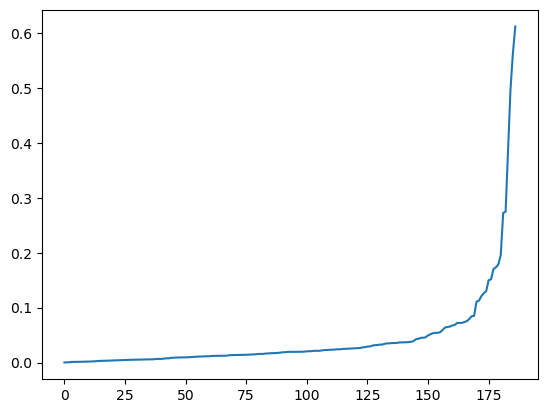

In [52]:
plt.plot(_tr)

In [ ]:
Xd = xgboost.DMatrix(X_train.values, label=y_train)
model = xgboost.train({"eta": 1, "max_depth": 6, "base_score": 0, "lambda": 0}, Xd, 1)
print("Model error =", np.linalg.norm(y_train - model.predict(Xd)))
print(model.get_dump(with_stats=True)[0])

In [ ]:
pred = model.predict(Xd, output_margin=True)
explainer = shap.TreeExplainer(model)
explanation = explainer(Xd)

shap_values = explanation.values
# make sure the SHAP values add up to marginal predictions
np.abs(shap_values.sum(axis=1) + explanation.base_values - pred).max()

In [ ]:
shap.plots.beeswarm(explanation)

In [ ]:
y_test.values[0]

In [ ]:
Xd = xgboost.DMatrix(X_test.values[0], label=y_test.values[0])
pred = model.predict(Xd, output_margin=True)
explainer = shap.TreeExplainer(model)
explanation = explainer(Xd)

shap_values = explanation.values
# make sure the SHAP values add up to marginal predictions
np.abs(shap_values.sum(axis=1) + explanation.base_values - pred).max()

In [ ]:
shap.plots.beeswarm(explanation)

In [ ]:
X_train_summary = shap.kmeans(X_train, 100)
ex = shap.KernelExplainer(best_model.predict, X_train_summary)

In [ ]:
ex = shap.KernelExplainer(best_model.predict, X_train_summary)
shap_values = ex.shap_values(X_test.iloc[0, :])
shap.force_plot(ex.expected_value, shap_values, X_test.iloc[0, :])

In [ ]:
# Calculate Shap values
shap_values = ex.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials, anneal
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
import numpy as np

# Define the hyperparameter space
space = {
    'loss': hp.choice('loss', ['squared_error', 'absolute_error', 'huber', 'quantile']),
    'learning_rate': hp.uniform('learning_rate', 0.01, 1),
    'n_estimators': hp.quniform('n_estimators', 10, 300, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'criterion': hp.choice('criterion', ['friedman_mse', 'squared_error']),
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 5, 1),
    'min_weight_fraction_leaf': hp.uniform('min_weight_fraction_leaf', 0.0, 0.5),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),  # now using quniform
    'min_impurity_decrease': hp.uniform('min_impurity_decrease', 0.0, 0.1),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2']),
    'alpha': hp.uniform('alpha', 0.01, 0.99),
    'max_leaf_nodes': hp.quniform('max_leaf_nodes', 10, 50, 1),  # now using quniform
    'validation_fraction': hp.uniform('validation_fraction', 0.1, 0.3),
#     'n_iter_no_change': hp.choice('n_iter_no_change', [None, 5, 10, 15]),
    'tol': hp.uniform('tol', 1e-5, 1e-3),
    'ccp_alpha': hp.uniform('ccp_alpha', 0.0, 0.1)
}

def objective(params):
    # Ensure integer parameters are properly cast
    params['n_estimators'] = int(params['n_estimators'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['max_depth'] = int(params['max_depth']) if params['max_depth'] is not None else None
    params['max_leaf_nodes'] = int(params['max_leaf_nodes']) if params['max_leaf_nodes'] is not None else None

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    model = GradientBoostingRegressor(random_state=42, **params)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae = -cross_val_score(model, X_scaled, y, cv=kf, scoring='neg_mean_absolute_error').mean()

    return {'loss': mae, 'status': STATUS_OK}


# Run the hyperparameter search using the Tree of Parzen Estimators (TPE) algorithm
trials = Trials()
best = fmin(fn=objective, space=space, algo=anneal.suggest, max_evals=100, trials=trials)

# Best hyperparameters
# best = {'learning_rate': 0.13, 'max_depth': 2, 'n_estimators': 300}
print("Best hyperparameters:", best)

# Map the indices to values for hp.choice parameters and ensure integer types
best = {
    'loss': ['squared_error', 'absolute_error', 'huber', 'quantile'][best['loss']],
    'criterion': ['friedman_mse', 'squared_error'][best['criterion']],
    'n_estimators': int(best['n_estimators']),
    'min_samples_split': int(best['min_samples_split']),
    'min_samples_leaf': int(best['min_samples_leaf']),
    'max_depth': int(best['max_depth']),
    'max_leaf_nodes': int(best['max_leaf_nodes']),
}

model = GradientBoostingRegressor(random_state=42, **best)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Evaluate the model using K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='neg_mean_squared_error')
mae_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='r2')

print(f"Average MSE: {-np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")
print(f"Average MAE: {-np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"Average R2: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")


In [ ]:
print(np.median(mse_scores)), print(np.median(mae_scores)), print(np.median(r2_scores))

In [ ]:
import numpy as np
from deap import base, creator, tools, algorithms
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from functools import partial
import multiprocessing

def customMutate(individual, param_bounds, indpb):
    for i, key in enumerate(param_bounds.keys()):
        if np.random.random() < indpb:  # Probability of mutation
            if isinstance(param_bounds[key], tuple):  # Numeric parameters
                # Mutate within the bounds
                bound = param_bounds[key]
                individual[i] = np.random.uniform(bound[0], bound[1])
            else:  # Categorical parameters
                # Randomly select a new category
                individual[i] = np.random.choice(param_bounds[key])
    return individual,


# Define the hyperparameter bounds
param_bounds = {
    'loss': ['squared_error', 'absolute_error', 'huber', 'quantile'],
    'learning_rate': (0.01, 1),
    'n_estimators': (10, 300),
    'subsample': (0.5, 1.0),
    'criterion': ['friedman_mse', 'squared_error'],
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 5),
    'min_weight_fraction_leaf': (0.0, 0.5),
    'max_depth': (3, 10),
    'min_impurity_decrease': (0.0, 0.1),
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': (0.0, 0.1)
}

# Create types
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Attribute generators
for param, bounds in param_bounds.items():
    if isinstance(bounds, tuple):  # Numeric parameter
        toolbox.register(param, np.random.uniform, bounds[0], bounds[1])
    else:  # Categorical parameter
        toolbox.register(param, np.random.choice, bounds)
        

# Individual and population
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.loss, toolbox.learning_rate, toolbox.n_estimators, toolbox.subsample,
                  toolbox.criterion, toolbox.min_samples_split, toolbox.min_samples_leaf,
                  toolbox.min_weight_fraction_leaf, toolbox.max_depth, toolbox.min_impurity_decrease,
                  toolbox.max_features, toolbox.ccp_alpha), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Evaluation function
def evalModel(individual, X_train, y_train):
    # Transform the individual genotype to a parameter dictionary
    param_names = list(param_bounds.keys())
    params = {param_names[i]: individual[i] for i in range(len(individual))}
    params['n_estimators'] = int(params['n_estimators'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['max_depth'] = int(params['max_depth'])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    model = GradientBoostingRegressor(random_state=42, **params)
    mae = -cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error').mean()
    
    return mae,

# Genetic operators
toolbox.register("evaluate", evalModel)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
# toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.1)
# Register the custom mutation function in the toolbox
toolbox.register("mutate", customMutate, param_bounds=param_bounds, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)

# Outer K-Fold Cross-validation to evaluate the final model performance
kf_outer = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores, mae_scores, r2_scores = [], [], []

for train_index, test_index in kf_outer.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Create a partial function of evalModel fixing X_train and y_train
    evalModel_partial = partial(evalModel, X_train=X_train, y_train=y_train)
    
    # Register the evaluation function with the partial function
    toolbox.register("evaluate", evalModel_partial)

    # Genetic Algorithm
    population = toolbox.population(n=50)
    hof = tools.HallOfFame(1)
    
    algorithms.eaSimple(population, toolbox, cxpb=0.5, mutpb=0.2, ngen=40, halloffame=hof, verbose=True)

    best_individual = hof[0]
    best_params = {list(param_bounds.keys())[i]: best_individual[i] for i in range(len(best_individual))}
    best_params['n_estimators'] = int(best_params['n_estimators'])
    best_params['min_samples_split'] = int(best_params['min_samples_split'])
    best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])
    best_params['max_depth'] = int(best_params['max_depth'])
    print(best_params)

    # Train the final model on the training data with the best hyperparameters
    model = GradientBoostingRegressor(random_state=42, **best_params)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Evaluate the model on the test set of the current fold
    mse_scores.append(mean_squared_error(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))

# Average performance across all folds
print(f"Average MSE: {np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")
print(f"Average MAE: {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"Average R2: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")


In [ ]:
import numpy as np
from deap import base, creator, tools, algorithms
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from functools import partial
import multiprocessing
from deap import tools, algorithms


def customMutate(individual, param_bounds, indpb):
    for i, key in enumerate(param_bounds.keys()):
        if np.random.random() < indpb:  # Probability of mutation
            if isinstance(param_bounds[key], tuple):  # Numeric parameters
                # Mutate within the bounds
                bound = param_bounds[key]
                individual[i] = np.random.uniform(bound[0], bound[1])
            else:  # Categorical parameters
                # Randomly select a new category
                individual[i] = np.random.choice(param_bounds[key])
    return individual,

# Define your `evalModel` function here
def evalModel(individual, X_train, y_train, param_bounds):
    param_names = list(param_bounds.keys())
    params = {param_names[i]: individual[i] for i in range(len(individual))}
    params['n_estimators'] = int(params['n_estimators'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['max_depth'] = int(params['max_depth'])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    model = GradientBoostingRegressor(random_state=42, **params)
    mae = -cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error').mean()
    
    return mae,

def main():
    # Hyperparameter bounds and other setup code...
    # Define the hyperparameter bounds
    param_bounds = {
        'loss': ['squared_error', 'absolute_error', 'huber', 'quantile'],
        'learning_rate': (0.01, 1),
        'n_estimators': (10, 300),
        'subsample': (0.5, 1.0),
        'criterion': ['friedman_mse', 'squared_error'],
        'min_samples_split': (2, 10),
        'min_samples_leaf': (1, 5),
        'min_weight_fraction_leaf': (0.0, 0.5),
        'max_depth': (3, 10),
        'min_impurity_decrease': (0.0, 0.1),
        'max_features': [None, 'sqrt', 'log2'],
        'ccp_alpha': (0.0, 0.1)
    }



    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()
    # Attribute generators
    for param, bounds in param_bounds.items():
        if isinstance(bounds, tuple):  # Numeric parameter
            toolbox.register(param, np.random.uniform, bounds[0], bounds[1])
        else:  # Categorical parameter
            toolbox.register(param, np.random.choice, bounds)


    # Individual and population
    toolbox.register("individual", tools.initCycle, creator.Individual,
                     (toolbox.loss, toolbox.learning_rate, toolbox.n_estimators, toolbox.subsample,
                      toolbox.criterion, toolbox.min_samples_split, toolbox.min_samples_leaf,
                      toolbox.min_weight_fraction_leaf, toolbox.max_depth, toolbox.min_impurity_decrease,
                      toolbox.max_features, toolbox.ccp_alpha), n=1)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    pool = multiprocessing.Pool()
    toolbox.register("map", pool.map)

    # Your genetic algorithm code...
    # Make sure to use partial to fix the parameters for evalModel
    evalModel_partial = partial(evalModel, param_bounds=param_bounds)

    # Genetic operators
    toolbox.register("evaluate", evalModel)
    toolbox.register("mate", tools.cxUniform, indpb=0.5)
    # toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.1)
    # Register the custom mutation function in the toolbox
    toolbox.register("mutate", customMutate, param_bounds=param_bounds, indpb=0.1)
    toolbox.register("select", tools.selTournament, tournsize=3)

    # Outer K-Fold Cross-validation and other operations...
    kf_outer = KFold(n_splits=5, shuffle=True, random_state=42)
    mse_scores, mae_scores, r2_scores = [], [], []

    for train_index, test_index in kf_outer.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Create a partial function of evalModel fixing X_train and y_train
        evalModel_partial = partial(evalModel, X_train=X_train, y_train=y_train)

        # Register the evaluation function with the partial function
        toolbox.register("evaluate", evalModel_partial)
        
        # Create statistics object
        stats = tools.Statistics(lambda ind: ind.fitness.values)
        stats.register("avg", np.mean)
        stats.register("std", np.std)
        stats.register("min", np.min)
        stats.register("max", np.max)

        pool = multiprocessing.Pool()
        toolbox.register("map", pool.map)

        # Genetic Algorithm
        population = toolbox.population(n=50)
        hof = tools.HallOfFame(1)

        result, log = algorithms.eaSimple(population, toolbox, 
                                          cxpb=0.5, mutpb=0.2, 
                                          ngen=40, stats=stats, 
                                          halloffame=hof, verbose=True)
        
#         # Print the log of each generation
#         for gen in log:
#             print(f"Generation: {gen['gen']}")
#             print(f"  Min MAE: {gen['min']}")
#             print(f"  Max MAE: {gen['max']}")
#             print(f"  Avg MAE: {gen['avg']}")
#             print(f"  Std Dev: {gen['std']}\n")

        best_individual = hof[0]
        best_params = {list(param_bounds.keys())[i]: best_individual[i] for i in range(len(best_individual))}
        best_params['n_estimators'] = int(best_params['n_estimators'])
        best_params['min_samples_split'] = int(best_params['min_samples_split'])
        best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])
        best_params['max_depth'] = int(best_params['max_depth'])
        print(best_params)

        # Train the final model on the training data with the best hyperparameters
        model = GradientBoostingRegressor(random_state=42, **best_params)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        # Evaluate the model on the test set of the current fold
        mse_scores.append(mean_squared_error(y_test, y_pred))
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))

    # Average performance across all folds
    print(f"Average MSE: {np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")
    print(f"Average MAE: {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
    print(f"Average R2: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")

if __name__ == '__main__':
    main()


In [ ]:
df = pd.DataFrame(zip(model.feature_names_in_, model.feature_importances_), columns = ['name', 'score'])

In [ ]:
df.sort_values(['score'], ascending=False)[0:30]

# Result Analysis

In [ ]:
X_test['WT dice'] = y_test.values
X_test['predicted WT dice'] = y_pred
X_test['difference'] = abs(y_test.values - y_pred)
X_test = X_test.round(2)

In [ ]:
wrong_cases = X_test[(X_test['WT dice'] >= WT_dice_threshold) 
                     & (X_test['predicted WT dice'] < WT_dice_threshold)]

all_cases = X_test[(X_test['WT dice'] >= WT_dice_threshold)]

reduce = wrong_cases[wrong_cases['difference'] <= mae].shape[0]

round(1 - ((wrong_cases.shape[0]-reduce)/all_cases.shape[0]),2), all_cases.shape[0], wrong_cases.shape[0]

In [ ]:
wrong_cases = X_test[(X_test['WT dice'] < WT_dice_threshold) 
                     & (X_test['predicted WT dice'] >= WT_dice_threshold)]

all_cases = X_test[(X_test['WT dice'] <  WT_dice_threshold)]

reduce = wrong_cases[wrong_cases['difference'] <= mae].shape[0]

round(1 - ((wrong_cases.shape[0]-reduce)/all_cases.shape[0]),2), all_cases.shape[0], wrong_cases.shape[0]

In [ ]:
failed_cases = X_test[(X_test['WT dice'] < WT_dice_threshold) 
                      & (X_test['predicted WT dice'] >= WT_dice_threshold)]
#                       & (wrong_cases['difference'] > mae)]

print(round(1 - failed_cases.shape[0]/X_test.shape[0], 2))

In [ ]:
X_test.shape[0]

In [ ]:
!pip install deap